In [3]:
# 데이터 불러오기

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'
df = pd.read_csv(path)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 데이터 전처리
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])


In [6]:
# 데이터 출력해서 확인
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [7]:
#label, feature 데이터 입력하

y=df['Rings']

X=df.drop(['id', 'Rings'],axis=1)

In [8]:
y.value_counts()
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [9]:
# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [11]:
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    layers.Dense(1)
    # Y.shape[1] = 클래스 개수, softmax = 확률로 변환
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 컴파일
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="mae",
    metrics=["mae"] # 평가 척
)

In [13]:
# 모델학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.9733 - mae: 5.9733 - val_loss: 2.7678 - val_mae: 2.7678
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2133 - mae: 2.2133 - val_loss: 1.7728 - val_mae: 1.7728
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9468 - mae: 1.9468 - val_loss: 1.6755 - val_mae: 1.6755
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8578 - mae: 1.8578 - val_loss: 1.6374 - val_mae: 1.6374
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8410 - mae: 1.8410 - val_loss: 1.6144 - val_mae: 1.6144
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7977 - mae: 1.7977 - val_loss: 1.6078 - val_mae: 1.6078
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7403 - mae: 1.7403 - val_loss: 1.6065 - val_mae: 1.6065
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7631 - mae: 1.7631 - val_loss: 1.5953 - val_mae: 1.5953
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [14]:

y_pred = model.predict(X_test) # 결과 = 확률


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [15]:
# 그래프 그리기용 데이터 저장
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']


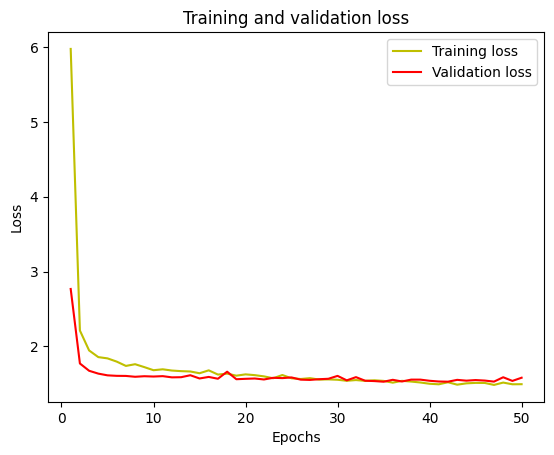

In [16]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


loss = history.history['loss'] # loss = 훈련 데이터 오차 /
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과

mae = history.history['mae']
val_mae = history.history['val_mae'] # 결과 척

epochs = range(1, len(loss) + 1) # x축 만들기

plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


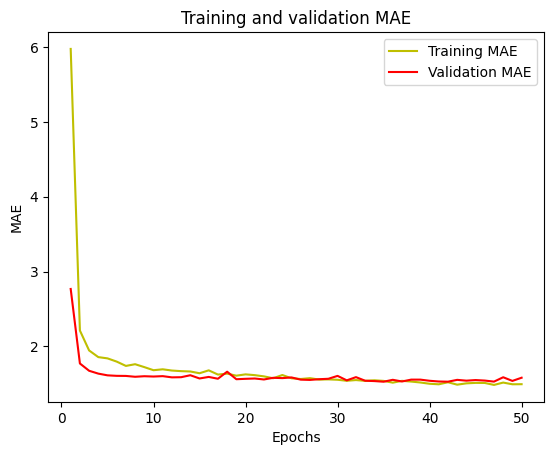

In [17]:
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [18]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

MAE : 1.4741895198822021
MSE : 4.478618621826172
RMSE: 2.116274703772214
